# 11. Learning Rate Schedulers

Finding the right Learning Rate (LR) is hard.
- **Too High**: Diverges.
- **Too Low**: Takes forever.

**Solution**: Start high, then lower it over time.
This is what **LR Schedulers** do.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## 1. Setup

We need an optimizer to attach the scheduler to.

In [2]:
model = nn.Linear(1, 1)
optimizer = optim.SGD(model.parameters(), lr=0.1)

## 2. StepLR

Decays the LR by a factor `gamma` every `step_size` epochs.
Example: Drop LR by half every 10 epochs.

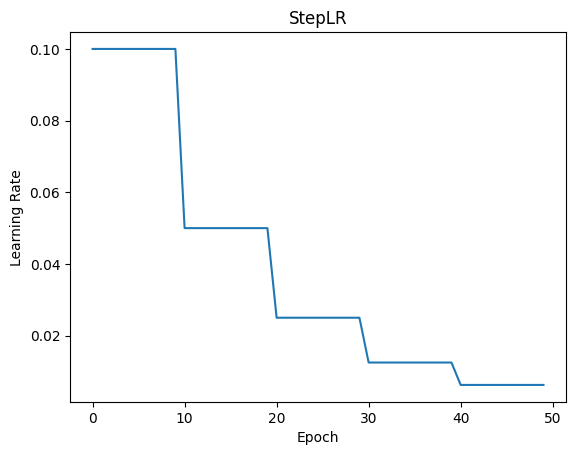

In [3]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

lrs = []
for epoch in range(50):
    optimizer.step() # Normally you'd do this after backward()
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step() # Update LR

plt.plot(lrs)
plt.title("StepLR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

## 3. CosineAnnealingLR

Smoothly decreases LR following a cosine curve. Very popular!

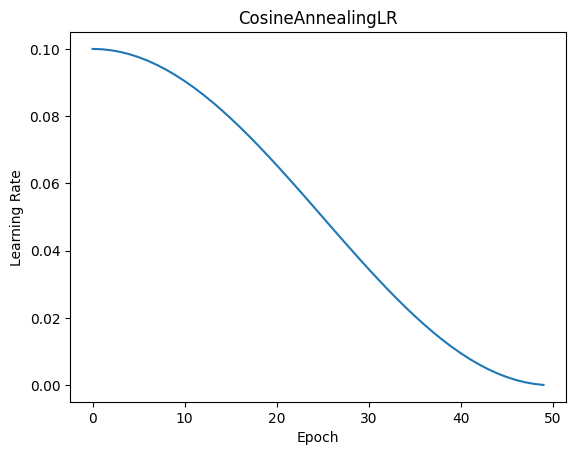

In [4]:
# Reset Optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

lrs = []
for epoch in range(50):
    optimizer.step()
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

plt.plot(lrs)
plt.title("CosineAnnealingLR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

## 4. Where to put it in the Training Loop?

```python
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

for epoch in range(epochs):
    train(...)
    validate(...)
    
    # Step the scheduler at the END of the epoch
    scheduler.step()
```

**Exception**: `ReduceLROnPlateau` steps after validation, using the validation loss:
```python
scheduler.step(val_loss)
```